In [3]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy import io, stats
import utils.drl as utils
from utils.plots import *
from utils.data import *
from utils.stats_perform import *

fig_dir = os.path.join('figures','lhb_data')
save_dir = os.path.join('analysis','lhb_data')
g_dir= '/Users/sromeropinto/Library/CloudStorage/GoogleDrive-sromeropinto@g.harvard.edu/My Drive/Data/LHb/Ju_LHb_Lesions/'


col_g = ['black','red']
groups = ['control','lesion']
nf = [45,44]
probs_cues = [10,50,90]

rseed =10
np.random.seed(rseed)


In [4]:

s = dict()
s['baselineWindow']      = [-1500, -500]  #% in units of milliseconds
s['psthWindow']          = [-1500, 4500]  #% in units of milliseconds
s['cueWindow']           = [0, 400]   # in units of milliseconds
s['traceWindow']         = [500, 2000]  #% in units of milliseconds
s['outcomeWindow']       = [2000, 2600] # % in units of milliseconds
s['outcomeWindowLate']       = [2200, 2600]  #% in units of milliseconds
s['outcomeWindowFreeLate']   = [200, 400]  #% in units of milliseconds
s['psthResolution']          = 2   #% in units of milliseconds
s['normalizeTo50']           = True # % when true, this will normalize the 50% responses for each cell according to the mean (across cells) of 50% responses in that animal.
s['smoothingTimeConst']      = 20;  #% 20 is what the eshel paper used (units of milliseconds)
s['interestingTrialTypes']   = np.arange(15)
s['maxTrialsPerType'] = 300
s['indeces'] = dict()
s['indeces']['puff80'] = [6,7]
s['indeces']['prob10']= [4,5]
s['indeces']['prob50'] = [2,3]
s['indeces']['prob90']= [0,1]
s['indeces']['freeRew'] = 8
s['indeces']['freePuff'] = 9
alpha_p = .05

loader_c = DataLoad(s)
data_path = os.path.join(g_dir,  'lightidunits',groups[0])
file_list = glob.glob(data_path + '/*formatteda.mat')
PSTH, PSTC, spikeRaster = loader_c.load_cells(file_list,response_type = 'spikes')
print('computing responses for '+ groups[0])
loader_c.compute_responses_re_baseline(PSTH)
PSTH_licks, PSTC_licks, lickRaster = loader_c.load_cells(file_list,response_type = 'licks')
_,_,_ =loader_c.compute_lick_responses(PSTH_licks)
loader_c.get_cells_same_day(file_list)

loader_l= DataLoad(s)
data_path = os.path.join(g_dir,  'lightidunits',groups[1])
file_list = glob.glob(data_path + '/*formatteda.mat')
PSTH, PSTC, spikeRaster = loader_l.load_cells(file_list,response_type = 'spikes')
loader_l.compute_responses_re_baseline(PSTH)
PSTH_licks, PSTC_licks, lickRaster = loader_l.load_cells(file_list,response_type = 'licks')
_,_,_=loader_l.compute_lick_responses(PSTH_licks)
loader_l.get_cells_same_day(file_list)

Cell 0 of 45
Cell 1 of 45
Cell 2 of 45
Cell 3 of 45
Cell 4 of 45
Cell 5 of 45
Cell 6 of 45
Cell 7 of 45
Cell 8 of 45
Cell 9 of 45
Cell 10 of 45
Cell 11 of 45
Cell 12 of 45
Cell 13 of 45
Cell 14 of 45
Cell 15 of 45
Cell 16 of 45
Cell 17 of 45
Cell 18 of 45
Cell 19 of 45
Cell 20 of 45
Cell 21 of 45
Cell 22 of 45
Cell 23 of 45
Cell 24 of 45
Cell 25 of 45
Cell 26 of 45
Cell 27 of 45
Cell 28 of 45
Cell 29 of 45
Cell 30 of 45
Cell 31 of 45
Cell 32 of 45
Cell 33 of 45
Cell 34 of 45
Cell 35 of 45
Cell 36 of 45
Cell 37 of 45
Cell 38 of 45
Cell 39 of 45
Cell 40 of 45
Cell 41 of 45
Cell 42 of 45
Cell 43 of 45
Cell 44 of 45
computing responses for control
Cell 0 of 45
Cell 1 of 45
Cell 2 of 45
Cell 3 of 45
Cell 4 of 45
Cell 5 of 45
Cell 6 of 45
Cell 7 of 45
Cell 8 of 45
Cell 9 of 45
Cell 10 of 45
Cell 11 of 45
Cell 12 of 45
Cell 13 of 45
Cell 14 of 45
Cell 15 of 45
Cell 16 of 45
Cell 17 of 45
Cell 18 of 45
Cell 19 of 45
Cell 20 of 45
Cell 21 of 45
Cell 22 of 45
Cell 23 of 45
Cell 24 of 45
Cell 25 

### Figure 6b 
Baseline responses 

The null hypothesis can be rejected: not drawn from a normal distribution


,name_test,pvals,stats,stat_name,group_nb,alternative,group_name,N
0,ranksum,0.01514,-2.429005,U-statistic,0.0,two-sided,baseline_all,"[45, 44]"
1,normaltest,"[3.428536519422752e-06, 3.3021511215437515e-06]","[25.166754117117016, 25.241872893687557]",s^2 + k^2,NaN,NaN,baseline_all,"[45, 44]"


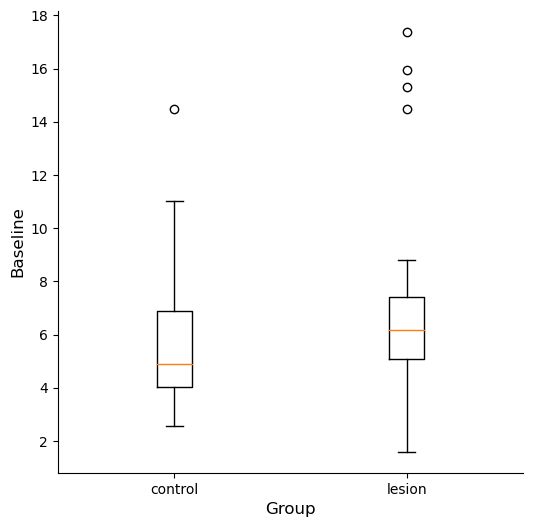

In [5]:

groups_test = [[loader_c.baselines,loader_l.baselines]]
name_suff = ['all']
name_preff = 'baseline'

tests_pd = get_tests_table(groups_test, name_preff, name_suff,restart_pd = True )
pvals = np.asarray(tests_pd[(tests_pd['name_test'] == 'ranksum') & (tests_pd['group_name'] == 'baseline_all')].pvals.to_numpy()[0])
stats_p = np.asarray(tests_pd[(tests_pd['name_test'] == 'ranksum') & (tests_pd['group_name'] == 'baseline_all')].stats.to_numpy()[0])
stats_n = np.asarray(tests_pd[(tests_pd['name_test'] == 'ranksum') & (tests_pd['group_name'] == 'baseline_all')].stat_name.to_numpy()[0])

fig,ax = plt.subplots(figsize=(6,6))
ax.boxplot([loader_c.baselines,loader_l.baselines])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.get_xaxis().tick_bottom()
ax.get_yaxis().tick_left()
ax.set_xlabel('Group',fontsize=12)
ax.set_ylabel('Baseline',fontsize=12)
ax.set_xticklabels(groups)
(tests_pd)

### Figure 4b
- Trace responses licks
- Trace responses licks (normalized)


The null hypothesis can be rejected: not drawn from a normal distribution
The null hypothesis can be rejected: not drawn from a normal distribution
The null hypothesis can be rejected: not drawn from a normal distribution


,name_test,pvals,stats,stat_name,group_nb,alternative,group_name,N
0,ranksum,0.000488,-3.487144,U-statistic,2.0,two-sided,licks_90,"[35, 30]"
1,ranksum,0.0,-5.57943,U-statistic,1.0,two-sided,licks_50,"[35, 30]"
2,ranksum,0.003792,-2.894987,U-statistic,0.0,two-sided,licks_10,"[35, 30]"
3,normaltest,"[2.526932043153472e-05, 0.30833642779922904, 0...","[21.171839058455056, 2.35312758816515, 5.32752...",s^2 + k^2,NaN,NaN,licks_all,"[35, 35, 35, 30, 30, 30]"


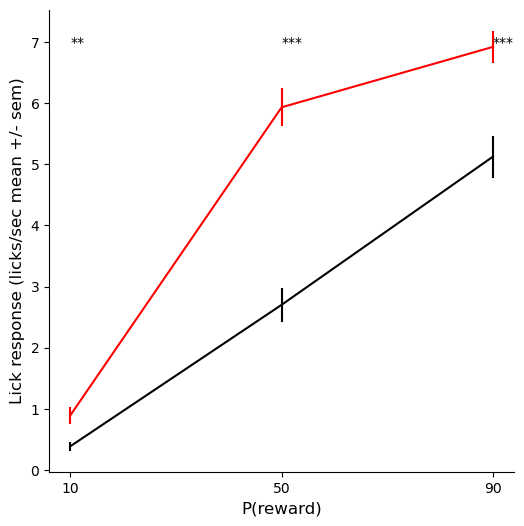

In [6]:
mu_across_cells_c,sem_across_cells_c,per_cell_c = loader_c.compute_mu_responses_per_cue(loader_c.traceResponses_licks,idU = loader_c.idU)
mu_across_cells_l,sem_across_cells_l,per_cell_l = loader_l.compute_mu_responses_per_cue(loader_l.traceResponses_licks,idU = loader_l.idU)

groups_test = [[per_cell_c[ii,:],per_cell_l[ii,:]] for ii in range(per_cell_l.shape[0])]
name_suff = ['10','50','90']
name_preff = 'licks'
tests_pd = get_tests_table(groups_test, name_preff, name_suff,restart_pd = True )
pvals = np.asarray([tests_pd[(tests_pd['name_test'] == 'ranksum') & (tests_pd['group_nb'] == ig)].pvals.to_numpy()[0] for ig in range(3)])
stats_p = np.asarray([tests_pd[(tests_pd['name_test'] == 'ranksum') & (tests_pd['group_nb'] == ig)].stats.to_numpy()[0] for ig in range(3)])
stats_n = np.asarray([tests_pd[(tests_pd['name_test'] == 'ranksum') & (tests_pd['group_nb'] == ig)].stat_name.to_numpy()[0] for ig in range(3)])
yy = np.max([mu_across_cells_c,mu_across_cells_l])

fig,ax = plt.subplots(figsize=(6,6))
ax.errorbar(probs_cues,mu_across_cells_c,sem_across_cells_c,color=col_g[0])
ax.errorbar(probs_cues,mu_across_cells_l,sem_across_cells_l,color=col_g[1])
[ax.text(probs_cues[ii],yy,get_pval_str(pv)) for (ii,pv) in enumerate(pvals)]
plot_config(ax,'P(reward)','Lick response (licks/sec mean +/- sem)',12,False)
ax.set_xticks(probs_cues)
tests_pd


The null hypothesis can be rejected: not drawn from a normal distribution


/var/folders/7s/h7n9pv413rl46rgzy1w1w54w0000gn/T/ipykernel_94083/3889490281.py:4: RuntimeWarning: invalid value encountered in divide
  per_cell_cn = (per_cell - np.nanmean(per_cell[0,:,:],axis=1)[np.newaxis,:,np.newaxis])/(np.nanmean(per_cell[2,:,:],axis=1)[np.newaxis,:,np.newaxis]-np.nanmean(per_cell[0,:,:],axis=1)[np.newaxis,:,np.newaxis])
/var/folders/7s/h7n9pv413rl46rgzy1w1w54w0000gn/T/ipykernel_94083/3889490281.py:5: RuntimeWarning: Mean of empty slice
  per_cell_cn = np.nanmean(per_cell_cn,axis=2)


,name_test,pvals,stats,stat_name,group_nb,alternative,group_name,N
0,ranksum,0.0,-6.444939,U-statistic,0.0,two-sided,lick_norm_50,"[42, 44]"
1,normaltest,"[0.32630007811498546, 0.0037830564629042977]","[2.239875671973348, 11.154446016023877]",s^2 + k^2,NaN,NaN,lick_norm_all,"[42, 44]"
2,ranksum,0.000488,-3.487144,U-statistic,2.0,two-sided,licks_90,"[35, 30]"
3,ranksum,0.0,-5.57943,U-statistic,1.0,two-sided,licks_50,"[35, 30]"
4,ranksum,0.003792,-2.894987,U-statistic,0.0,two-sided,licks_10,"[35, 30]"
5,normaltest,"[2.526932043153472e-05, 0.30833642779922904, 0...","[21.171839058455056, 2.35312758816515, 5.32752...",s^2 + k^2,NaN,NaN,licks_all,"[35, 35, 35, 30, 30, 30]"


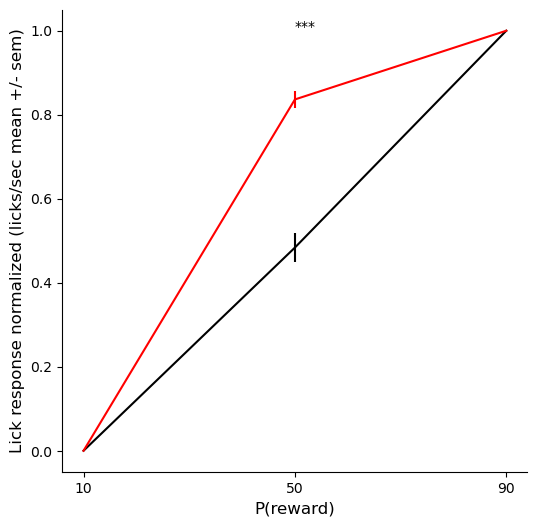

In [7]:
indeces_resp = [loader_l.indeces_prob10,loader_l.indeces_prob50,loader_l.indeces_prob90]
responses = loader_c.traceResponses_licks 
per_cell = np.asarray([np.reshape(responses[:,ii,:],(responses.shape[0],-1))  for ii in indeces_resp])
per_cell_cn = (per_cell - np.nanmean(per_cell[0,:,:],axis=1)[np.newaxis,:,np.newaxis])/(np.nanmean(per_cell[2,:,:],axis=1)[np.newaxis,:,np.newaxis]-np.nanmean(per_cell[0,:,:],axis=1)[np.newaxis,:,np.newaxis])
per_cell_cn = np.nanmean(per_cell_cn,axis=2)
per_cell_cn_50 = per_cell_cn[1,~np.isnan(per_cell_cn[1,:])]
responses = loader_l.traceResponses_licks 
per_cell = np.asarray([np.reshape(responses[:,ii,:],(responses.shape[0],-1))  for ii in indeces_resp])
per_cell_ln = (per_cell - np.nanmean(per_cell[0,:,:],axis=1)[np.newaxis,:,np.newaxis])/(np.nanmean(per_cell[2,:,:],axis=1)[np.newaxis,:,np.newaxis]-np.nanmean(per_cell[0,:,:],axis=1)[np.newaxis,:,np.newaxis])
per_cell_ln = np.nanmean(per_cell_ln,axis=2)
per_cell_ln_50 = per_cell_ln[1,~np.isnan(per_cell_ln[1,:])]

mu_across_cells_c,sem_across_cells_c = np.nanmean(per_cell_cn,axis=1),np.nanstd(per_cell_cn,axis=1)/np.sqrt(per_cell_cn.shape[1])
mu_across_cells_l,sem_across_cells_l = np.nanmean(per_cell_ln,axis=1),np.nanstd(per_cell_ln,axis=1)/np.sqrt(per_cell_ln.shape[1])

groups_test = [[per_cell_cn_50,per_cell_ln_50] ]
name_suff = ['50']
name_preff = 'lick_norm' 
tests_pd = get_tests_table(groups_test, name_preff, name_suff,restart_pd = False ,tests_pd=tests_pd)
pvals = np.asarray([tests_pd[(tests_pd['name_test'] == 'ranksum') & (tests_pd['group_nb'] == 0)].pvals.to_numpy()[0] ])
stats_p = np.asarray([tests_pd[(tests_pd['name_test'] == 'ranksum') & (tests_pd['group_nb'] ==0)].stats.to_numpy()[0]])
stats_n = np.asarray([tests_pd[(tests_pd['name_test'] == 'ranksum') & (tests_pd['group_nb'] == 0)].stat_name.to_numpy()[0] ])

yy = np.max([mu_across_cells_c,mu_across_cells_l])
fig,ax = plt.subplots(figsize=(6,6))
ax.errorbar(probs_cues,mu_across_cells_c,sem_across_cells_c,color=col_g[0])
ax.errorbar(probs_cues,mu_across_cells_l,sem_across_cells_l,color=col_g[1])
[ax.text(probs_cues[1],yy,get_pval_str(pv)) for (ii,pv) in enumerate(pvals)]
plot_config(ax,'P(reward)','Lick response normalized (licks/sec mean +/- sem)',12,False)
ax.set_xticks(probs_cues)
tests_pd

### Figure 4d 
- Cue responses raw
- Cue responses normalized

The null hypothesis can be rejected: not drawn from a normal distribution
The null hypothesis can be rejected: not drawn from a normal distribution
The null hypothesis can be rejected: not drawn from a normal distribution


,name_test,pvals,stats,stat_name,group_nb,alternative,group_name,N
0,ranksum,0.001156,3.249615,U-statistic,2.0,two-sided,cue_raw_90,"[45, 44]"
1,ranksum,0.332885,0.96832,U-statistic,1.0,two-sided,cue_raw_50,"[45, 44]"
2,ranksum,0.122892,1.542747,U-statistic,0.0,two-sided,cue_raw_10,"[45, 44]"
3,normaltest,"[0.0016314536846375126, 0.06202703172113622, 0...","[12.836567661085095, 5.56036998690654, 3.85588...",s^2 + k^2,NaN,NaN,cue_raw_all,"[45, 45, 45, 44, 44, 44]"
4,ranksum,0.0,-6.444939,U-statistic,0.0,two-sided,lick_norm_50,"[42, 44]"
5,normaltest,"[0.32630007811498546, 0.0037830564629042977]","[2.239875671973348, 11.154446016023877]",s^2 + k^2,NaN,NaN,lick_norm_all,"[42, 44]"
6,ranksum,0.000488,-3.487144,U-statistic,2.0,two-sided,licks_90,"[35, 30]"
7,ranksum,0.0,-5.57943,U-statistic,1.0,two-sided,licks_50,"[35, 30]"
8,ranksum,0.003792,-2.894987,U-statistic,0.0,two-sided,licks_10,"[35, 30]"
9,normaltest,"[2.526932043153472e-05, 0.30833642779922904, 0...","[21.171839058455056, 2.35312758816515, 5.32752...",s^2 + k^2,NaN,NaN,licks_all,"[35, 35, 35, 30, 30, 30]"


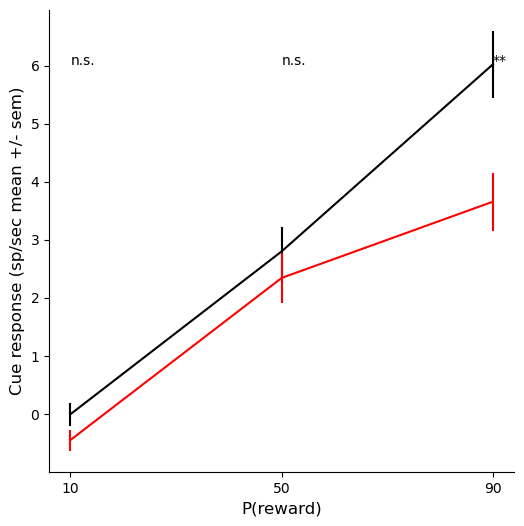

In [8]:

mu_across_cells_c,sem_across_cells_c,per_cell_c = loader_c.compute_mu_responses_per_cue(loader_c.cueResponses)
mu_across_cells_l,sem_across_cells_l,per_cell_l = loader_l.compute_mu_responses_per_cue(loader_l.cueResponses)
alpha_p = .05
groups_test = [[per_cell_c[ii,:],per_cell_l[ii,:]] for ii in range(per_cell_l.shape[0])]
name_suff = ['10','50','90']
name_preff = 'cue_raw'
tests_pd = get_tests_table(groups_test, name_preff, name_suff,restart_pd = False ,tests_pd=tests_pd,alpha_p=alpha_p)
pvals = np.asarray([tests_pd[(tests_pd['name_test'] == 'ranksum') & (tests_pd['group_nb'] == ig)].pvals.to_numpy()[0] for ig in range(3)])
stats_p = np.asarray([tests_pd[(tests_pd['name_test'] == 'ranksum') & (tests_pd['group_nb'] == ig)].stats.to_numpy()[0] for ig in range(3)])
stats_n = np.asarray([tests_pd[(tests_pd['name_test'] == 'ranksum') & (tests_pd['group_nb'] == ig)].stat_name.to_numpy()[0] for ig in range(3)])
yy = np.max([mu_across_cells_c,mu_across_cells_l])
fig,ax = plt.subplots(figsize=(6,6))
ax.errorbar(probs_cues,mu_across_cells_c,sem_across_cells_c,color=col_g[0])
ax.errorbar(probs_cues,mu_across_cells_l,sem_across_cells_l,color=col_g[1])
[ax.text(probs_cues[ii],yy,get_pval_str(pv)) for (ii,pv) in enumerate(pvals)]
plot_config(ax,'P(reward)','Cue response (sp/sec mean +/- sem)',12,False)
ax.set_xticks(probs_cues)
(tests_pd)


The null hypothesis can be rejected: not drawn from a normal distribution


,name_test,pvals,stats,stat_name,group_nb,alternative,group_name,N
0,ranksum,0.000131,-3.824042,U-statistic,0.0,two-sided,cue_norm_50,"[45, 44]"
1,normaltest,"[5.444750246393421e-14, 5.256921555465289e-07]","[61.08307883002933, 28.917100102305167]",s^2 + k^2,NaN,NaN,cue_norm_all,"[45, 44]"
2,ranksum,0.001156,3.249615,U-statistic,2.0,two-sided,cue_raw_90,"[45, 44]"
3,ranksum,0.332885,0.96832,U-statistic,1.0,two-sided,cue_raw_50,"[45, 44]"
4,ranksum,0.122892,1.542747,U-statistic,0.0,two-sided,cue_raw_10,"[45, 44]"
5,normaltest,"[0.0016314536846375126, 0.06202703172113622, 0...","[12.836567661085095, 5.56036998690654, 3.85588...",s^2 + k^2,NaN,NaN,cue_raw_all,"[45, 45, 45, 44, 44, 44]"
6,ranksum,0.0,-6.444939,U-statistic,0.0,two-sided,lick_norm_50,"[42, 44]"
7,normaltest,"[0.32630007811498546, 0.0037830564629042977]","[2.239875671973348, 11.154446016023877]",s^2 + k^2,NaN,NaN,lick_norm_all,"[42, 44]"
8,ranksum,0.000488,-3.487144,U-statistic,2.0,two-sided,licks_90,"[35, 30]"
9,ranksum,0.0,-5.57943,U-statistic,1.0,two-sided,licks_50,"[35, 30]"


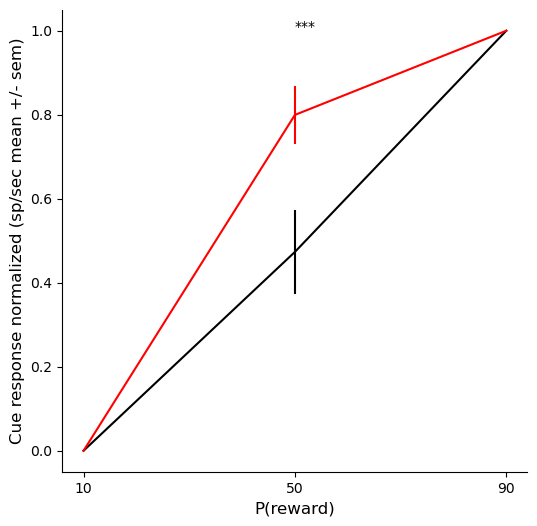

In [9]:
indeces_resp = [loader_l.indeces_prob10,loader_l.indeces_prob50,loader_l.indeces_prob90]
responses = loader_l.cueResponses 
per_cell = np.asarray([np.reshape(responses[:,ii,:],(responses.shape[0],-1))  for ii in indeces_resp])
per_cell_ln = (per_cell - np.nanmean(per_cell[0,:,:],axis=1)[np.newaxis,:,np.newaxis])/(np.nanmean(per_cell[2,:,:],axis=1)[np.newaxis,:,np.newaxis]-np.nanmean(per_cell[0,:,:],axis=1)[np.newaxis,:,np.newaxis])
per_cell_ln = np.nanmean(per_cell_ln,axis=2)

responses = loader_c.cueResponses 
per_cell = np.asarray([np.reshape(responses[:,ii,:],(responses.shape[0],-1))  for ii in indeces_resp])
per_cell_cn = (per_cell - np.nanmean(per_cell[0,:,:],axis=1)[np.newaxis,:,np.newaxis])/(np.nanmean(per_cell[2,:,:],axis=1)[np.newaxis,:,np.newaxis]-np.nanmean(per_cell[0,:,:],axis=1)[np.newaxis,:,np.newaxis])
per_cell_cn = np.nanmean(per_cell_cn,axis=2)
mu_across_cells_c,sem_across_cells_c = np.nanmean(per_cell_cn,axis=1),np.nanstd(per_cell_cn,axis=1)/np.sqrt(per_cell_cn.shape[1])
mu_across_cells_l,sem_across_cells_l = np.nanmean(per_cell_ln,axis=1),np.nanstd(per_cell_ln,axis=1)/np.sqrt(per_cell_ln.shape[1])

alpha_p = .05
groups_test = [[per_cell_cn[1,:],per_cell_ln[1,:]] ]
name_suff = ['50']
name_preff = 'cue_norm' 
tests_pd = get_tests_table(groups_test, name_preff, name_suff,restart_pd = False ,tests_pd=tests_pd)
pvals = np.asarray([tests_pd[(tests_pd['name_test'] == 'ranksum') & (tests_pd['group_nb'] == 0)].pvals.to_numpy()[0] ])
stats_p = np.asarray([tests_pd[(tests_pd['name_test'] == 'ranksum') & (tests_pd['group_nb'] ==0)].stats.to_numpy()[0]])
stats_n = np.asarray([tests_pd[(tests_pd['name_test'] == 'ranksum') & (tests_pd['group_nb'] == 0)].stat_name.to_numpy()[0] ])

yy = np.max([mu_across_cells_c,mu_across_cells_l])
fig,ax = plt.subplots(figsize=(6,6))
ax.errorbar(probs_cues,mu_across_cells_c,sem_across_cells_c,color=col_g[0])
ax.errorbar(probs_cues,mu_across_cells_l,sem_across_cells_l,color=col_g[1])
[ax.text(probs_cues[1],yy,get_pval_str(pv)) for (ii,pv) in enumerate(pvals)]
plot_config(ax,'P(reward)','Cue response normalized (sp/sec mean +/- sem)',12,False)
ax.set_xticks(probs_cues)
tests_pd


### Figure 5c
- Outcome responses 

The null hypothesis can be rejected: not drawn from a normal distribution
The null hypothesis can be rejected: not drawn from a normal distribution
The null hypothesis can be rejected: not drawn from a normal distribution
The null hypothesis can be rejected: not drawn from a normal distribution
The null hypothesis can be rejected: not drawn from a normal distribution
The null hypothesis can be rejected: not drawn from a normal distribution


/Users/sromeropinto/Dropbox (Uchida Lab)/Sandra Romeo/Manuscript D1D2/code/D1D2_Dopamine/utils/data.py:484: RuntimeWarning: Mean of empty slice
  mu_across_cells = np.asarray([np.nanmean(np.nanmean(responses[:,ii,:],axis=1),axis=0)
/Users/sromeropinto/Dropbox (Uchida Lab)/Sandra Romeo/Manuscript D1D2/code/D1D2_Dopamine/utils/data.py:487: RuntimeWarning: Mean of empty slice
  sem_across_cells = np.asarray([np.nanstd(np.nanmean(responses[:,ii,:],axis=1),axis=0)/np.sqrt(responses.shape[0])
/Users/sromeropinto/Dropbox (Uchida Lab)/Sandra Romeo/Manuscript D1D2/code/D1D2_Dopamine/utils/data.py:489: RuntimeWarning: Mean of empty slice
  per_cell = np.asarray([ np.nanmean(responses[:,ii,:],axis=1)


,name_test,pvals,stats,stat_name,group_nb,alternative,group_name,N
0,ranksum,0.002814,2.987314,U-statistic,5.0,two-sided,outcome_90,"[45, 44]"
1,ranksum,0.000195,3.725569,U-statistic,4.0,two-sided,outcome_50,"[45, 44]"
2,ranksum,0.042672,2.026907,U-statistic,3.0,two-sided,outcome_10,"[45, 44]"
3,ranksum,0.485478,-0.697518,U-statistic,2.0,two-sided,outcome_-10,"[45, 44]"
4,ranksum,0.050813,-1.953052,U-statistic,1.0,two-sided,outcome_-50,"[45, 44]"
5,ranksum,0.000001,-4.940072,U-statistic,0.0,two-sided,outcome_-90,"[45, 44]"
6,normaltest,"[3.565801013209166e-08, 2.947846895035473e-09,...","[34.298584054374984, 39.28438159833256, 11.639...",s^2 + k^2,NaN,NaN,outcome_all,"[45, 45, 45, 45, 45, 45, 44, 44, 44, 44, 44, 44]"
7,ranksum,0.000131,-3.824042,U-statistic,0.0,two-sided,cue_norm_50,"[45, 44]"
8,normaltest,"[5.444750246393421e-14, 5.256921555465289e-07]","[61.08307883002933, 28.917100102305167]",s^2 + k^2,NaN,NaN,cue_norm_all,"[45, 44]"
9,ranksum,0.001156,3.249615,U-statistic,2.0,two-sided,cue_raw_90,"[45, 44]"


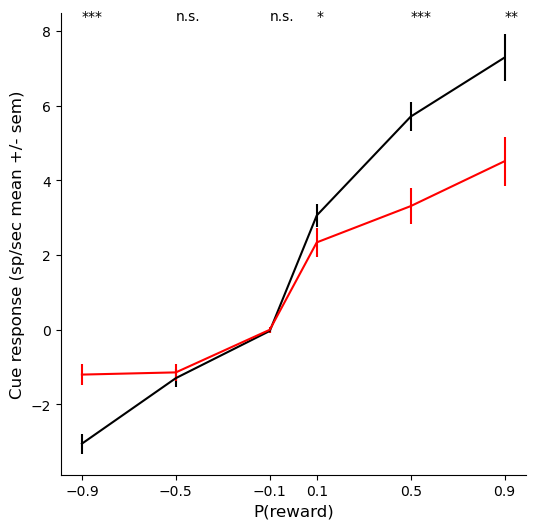

In [10]:
alpha_p = .05
mu_across_cells_c,sem_across_cells_c,per_cell_c = loader_c.compute_mu_responses_per_cue_outcome(loader_c.outcomeResponses)
mu_across_cells_l,sem_across_cells_l,per_cell_l = loader_l.compute_mu_responses_per_cue_outcome(loader_l.outcomeResponses)
groups_test = [[per_cell_c[ii,:],per_cell_l[ii,:]] for ii in range(per_cell_l.shape[0])]
name_suff = ['-90','-50','-10','10','50','90']
rpes_x = [-.9,-.5,-.1,.1,.5,.9]
name_preff = 'outcome'
tests_pd = get_tests_table(groups_test, name_preff, name_suff,restart_pd = False ,tests_pd=tests_pd)
pvals = np.asarray([tests_pd[(tests_pd['name_test'] == 'ranksum') & (tests_pd['group_nb'] == ig)].pvals.to_numpy()[0] for ig in range(6)])
stats_p = np.asarray([tests_pd[(tests_pd['name_test'] == 'ranksum') & (tests_pd['group_nb'] == ig)].stats.to_numpy()[0] for ig in range(6)])
yy = np.max([mu_across_cells_c,mu_across_cells_l])+1
fig,ax = plt.subplots(figsize=(6,6))
ax.errorbar(rpes_x,mu_across_cells_c,sem_across_cells_c,color=col_g[0])
ax.errorbar(rpes_x,mu_across_cells_l,sem_across_cells_l,color=col_g[1])
[ax.text(rpes_x[ii],yy,get_pval_str(pv)) for (ii,pv) in enumerate(pvals)]
plot_config(ax,'P(reward)','Cue response (sp/sec mean +/- sem)',12,False)
ax.set_xticks(rpes_x)
(tests_pd)
  

### Figure 4e
- Compute t-statistic
- Monte carlo tests for t-statistic distribution 

[0.021739130434782608, 1.0]
[0.022222222222222223, 0.022222222222222223]
The null hypothesis can be rejected: not drawn from a normal distribution


,name_test,pvals,stats,stat_name,group_nb,alternative,group_name,N
0,ranksum,0.002441,-2.814692,U-statistic,0.0,less,tstat_50,"[45, 44]"
1,normaltest,"[0.3046960223401306, 5.989733578379219e-07]","[2.376881294847587, 28.65609743510629]",s^2 + k^2,NaN,NaN,tstat_all,"[45, 44]"
2,MC_tstat_std,0.022222,4.487811,greater,1.0,NaN,lesion,44
3,MC_tstat_mean,1.0,1.930157,lower,1.0,NaN,lesion,44
4,MC_tstat_mean,0.022222,1.930157,greater,1.0,NaN,lesion,44
5,MC_tstat_std,0.021739,4.090679,greater,0.0,NaN,control,45
6,MC_tstat_mean,0.021739,-0.655243,lower,0.0,NaN,control,45
7,MC_tstat_mean,1.0,-0.655243,greater,0.0,NaN,control,45
8,ranksum,0.002814,2.987314,U-statistic,5.0,two-sided,outcome_90,"[45, 44]"
9,ranksum,0.000195,3.725569,U-statistic,4.0,two-sided,outcome_50,"[45, 44]"


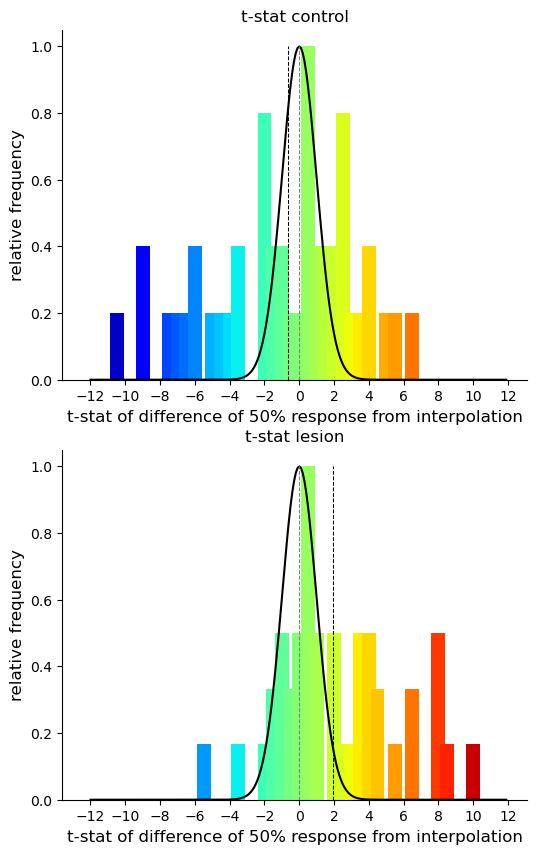

In [11]:
typeMedian = 'both'
indeces_resp = [loader_l.indeces_prob10,loader_l.indeces_prob50,loader_l.indeces_prob90]
responses = loader_l.cueResponses 
per_cell_l = np.asarray([np.reshape(responses[:,ii,:],(responses.shape[0],-1))  for ii in indeces_resp])
responses  = loader_c.cueResponses 
per_cell_c = np.asarray([np.reshape(responses[:,ii,:],(responses.shape[0],-1))  for ii in indeces_resp])
c10_l, c50_l, c90_l = per_cell_l[0,:,:],per_cell_l[1,:,:],per_cell_l[2,:,:]
c10_c, c50_c, c90_c = per_cell_c[0,:,:],per_cell_c[1,:,:],per_cell_c[2,:,:]
c10, c50, c90 = per_cell_c[0,:,:],per_cell_c[1,:,:],per_cell_c[2,:,:]
cueKinkiness_c,kinkPvals_c,medNames_c = calculate_kinkiness(c10, c50, c90, typeMedian)
c10, c50, c90 = per_cell_l[0,:,:],per_cell_l[1,:,:],per_cell_l[2,:,:]
cueKinkiness_l,kinkPvals_l,medNames_l = calculate_kinkiness(c10, c50, c90, typeMedian)

x = np.arange(-12,12,0.1)
df = 100
type_kink = 1
fig,ax  =plt.subplots(2,1,figsize=(6,10))
vKinkiness  = [cueKinkiness_c[:,type_kink],cueKinkiness_l[:,type_kink]]
for iss in range(2):
    [ckhist, hcenters] = np.histogram(vKinkiness[iss], np.arange(-12,12,step=.5))
    ckhist = ckhist / max(ckhist)
    for ih in range(len(ckhist)):
        ax[iss].bar(hcenters[ih], ckhist[ih],color=cm.jet(ih/len(ckhist)))
    rr = stats.t(df)
    tpdfcurve = rr.pdf(x)
    tpdfcurve = tpdfcurve / max(tpdfcurve)
    ax[iss].plot(x, tpdfcurve, 'k-')
    ax[iss].plot([0, 0], [0, 1],color='grey',linestyle='--',linewidth=.75)
    ax[iss].plot(   [np.nanmean(vKinkiness[iss]),np.nanmean(vKinkiness[iss])],[0,1],color='black',linestyle='--',linewidth=.75)
    ax[iss].set_xticks(np.arange(-12,14,2))
    ax[iss].set_title('t-stat '+groups[iss])
    plot_config(ax[iss],'t-stat of difference of 50% response from interpolation','relative frequency',12,False)

#%% Monte carlo tests for t-statistic distribution 
type_kink = 1
vKinkiness  = [cueKinkiness_c[:,type_kink],cueKinkiness_l[:,type_kink]]
pvals_kinkiness = []
for  (ix,x) in enumerate(vKinkiness):
    res_std = compute_monte_carlo(x,statistic_std,int(len(x)),rvs_type = 'students-t',alternative='greater',batch =100)
    res_mean = compute_monte_carlo(x,statistic_mean,int(len(x)),rvs_type = 'students-t',alternative='greater',batch =100)
    res_mean_lo = compute_monte_carlo(x,statistic_mean,int(len(x)),rvs_type = 'students-t',alternative='less',batch =100)

    print([res_std.pvalue,res_mean.pvalue,])#res_median.pvalue])
    pvals_kinkiness.append([res_std.pvalue,res_mean.pvalue])#,res_median.pvalue])
    new_row =  pd.DataFrame({   'name_test':['MC_tstat_mean'],  'pvals':[res_mean.pvalue],'stats':[res_mean.statistic],
                                'stat_name': ['greater'],  'group_nb':[ix],'group_name':[ groups[ix]] ,'N':[len(x)]  })
    tests_pd = pd.concat([new_row,tests_pd.loc[:]]).reset_index(drop=True)

    new_row =  pd.DataFrame({   'name_test':['MC_tstat_mean'],  'pvals':[res_mean_lo.pvalue],'stats':[res_mean_lo.statistic],
                                'stat_name': ['lower'],  'group_nb':[ix],'group_name':[ groups[ix]] ,'N':[len(x)]  })
    tests_pd = pd.concat([new_row,tests_pd.loc[:]]).reset_index(drop=True)
    
    new_row =  pd.DataFrame({   'name_test':['MC_tstat_std'],  'pvals':[res_std.pvalue],'stats':[res_std.statistic],
                                    'stat_name': ['greater'],  'group_nb':[ix],'group_name':[ groups[ix]] ,'N':[len(x)]  })
    tests_pd = pd.concat([new_row,tests_pd.loc[:]]).reset_index(drop=True)

tests_pd
#%%  Test for t-stat between groups
type_kink = 1
groups_test =  [[cueKinkiness_c[:,type_kink],cueKinkiness_l[:,type_kink]]]
name_suff = ['50']
name_preff = 'tstat'
alternative = 'less'
tests_pd = get_tests_table(groups_test, name_preff, name_suff,restart_pd = False ,tests_pd=tests_pd,alternative=alternative)
tests_pd


### Figure 5d
- Compute taus from single cells
- Compute taus from population 

The null hypothesis cannot be rejected


/var/folders/7s/h7n9pv413rl46rgzy1w1w54w0000gn/T/ipykernel_94083/149007371.py:14: RuntimeWarning: Mean of empty slice
  utility_axis = np.floor(np.nanmean(np.nanmean(per_cell,axis=2),axis=0)*1000)/1000


,name_test,pvals,stats,stat_name,alternative,group_nb,group_name,N
0,ttest,0.508048,0.02024,t-statistic,less,0.0,tstat_taus,"[44, 36]"
1,normaltest,"[0.15173967747906555, 0.10851831524397221]","[3.7711777491168323, 4.441672632311041]",s^2 + k^2,NaN,NaN,tstat_all,"[44, 36]"
2,MC_tstat_mean_taus,0.6,-0.010361,greater,NaN,1.0,lesion,36
3,MC_tstat_mean_taus,0.555556,-0.009236,greater,NaN,0.0,control,44
4,ranksum,0.002441,-2.814692,U-statistic,less,0.0,tstat_50,"[45, 44]"
5,normaltest,"[0.3046960223401306, 5.989733578379219e-07]","[2.376881294847587, 28.65609743510629]",s^2 + k^2,NaN,NaN,tstat_all,"[45, 44]"
6,MC_tstat_std,0.022222,4.487811,greater,NaN,1.0,lesion,44
7,MC_tstat_mean,1.0,1.930157,lower,NaN,1.0,lesion,44
8,MC_tstat_mean,0.022222,1.930157,greater,NaN,1.0,lesion,44
9,MC_tstat_std,0.021739,4.090679,greater,NaN,0.0,control,45


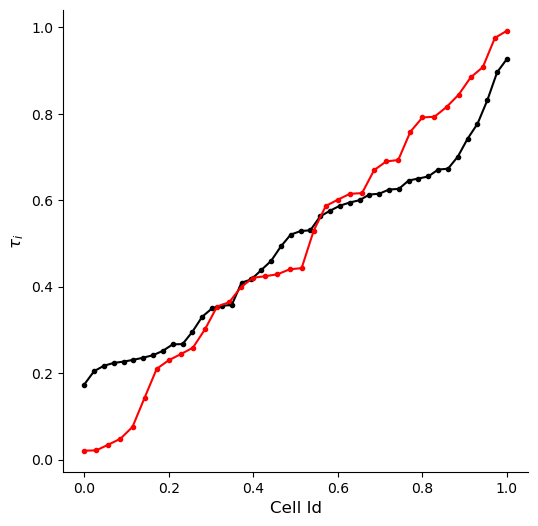

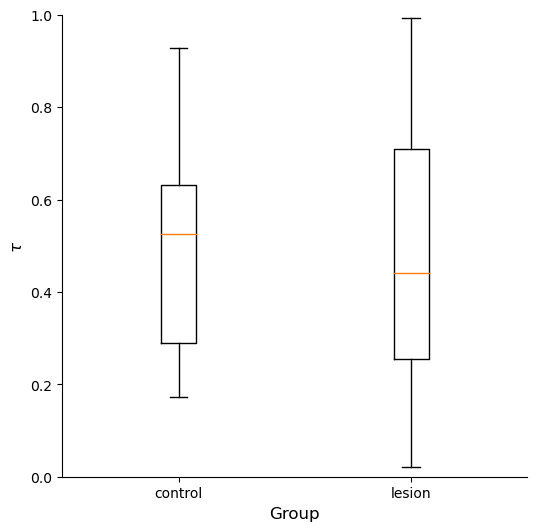

In [12]:
#%% Compute taus from firing rates:
indeces_resp = [loader_l.indeces_prob90[1],loader_l.indeces_prob50[1],loader_l.indeces_prob10[1],
                loader_l.indeces_prob90[0],loader_l.indeces_prob50[0],loader_l.indeces_prob10[0],]
# Format FR to: (n_cells,n_types,n_trials) 
per_cell_l = np.asarray([loader_l.outcomeResponses[:,ii,:] for ii in indeces_resp])
per_cell_c = np.asarray([loader_c.outcomeResponses[:,ii,:] for ii in indeces_resp])

#% =% Compute taus and zerocrossing poitns
method_zcross='count'
groups_resp = [per_cell_c,per_cell_l]
taus_v,id_disc,zcross_v,zcross_rpev,apos,aneg = [],[],[],[],[],[]
for iresp in groups_resp:
    per_cell = iresp.copy().transpose(1,0,2)
    utility_axis = np.floor(np.nanmean(np.nanmean(per_cell,axis=2),axis=0)*1000)/1000
    m = [utils.compute_drl_metrics(per_cell[i_cell,:,:],utility_axis,method_zcross) for i_cell in range(per_cell.shape[0])]
    taus_,alpha_pos,alpha_neg,zcross_util,zcross_rpe,i_disc = utils.extract_metrics(m,[utility_axis for _ in range(len(m))],rpes_x)
    taus_v.append(taus_)
    zcross_v.append(zcross_util)
    apos.append(alpha_pos)
    aneg.append(alpha_neg)
    zcross_rpev.append(zcross_rpe)
    id_disc.append(i_disc)
#% % Figure 5d:
fig,ax = plt.subplots(figsize=(6,6))
ax.plot(np.linspace(0,1,len(np.sort(taus_v[0]))),np.sort(taus_v[0]),'.',color='black')
ax.plot(np.linspace(0,1,len(np.sort(taus_v[1]))),np.sort(taus_v[1]),'.',color='red')
ax.plot(np.linspace(0,1,len(np.sort(taus_v[0]))),np.sort(taus_v[0]),color='black')
ax.plot(np.linspace(0,1,len(np.sort(taus_v[1]))),np.sort(taus_v[1]),color='red')
plot_config(ax,'Cell Id',r'$\tau_i$',12,False)


fig,ax = plt.subplots(figsize=(6,6))
ax.boxplot([taus_v[0],taus_v[1]])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.get_xaxis().tick_bottom()
ax.get_yaxis().tick_left()
ax.set_xlabel('Group',fontsize=12)
ax.set_ylabel(r'$\tau$',fontsize=12)
ax.set_xticklabels(groups)
ax.set_ylim([0,1])


#% %
# Test for means different from 0.5:
for (ix,itau) in enumerate(taus_v):
    res_mean = compute_monte_carlo(itau-.5,statistic_mean,int(len(x)),rvs_type = 'students-t',alternative='greater',batch =100)
    new_row =  pd.DataFrame({   'name_test':['MC_tstat_mean_taus'],  'pvals':[res_mean.pvalue],'stats':[res_mean.statistic],
                                    'stat_name': ['greater'],  'group_nb':[ix],'group_name':[ groups[ix]] ,'N':[len(itau)]  })
    tests_pd = pd.concat([new_row,tests_pd.loc[:]]).reset_index(drop=True)
# Test for difference between distributions : 
groups_test =  [[taus_v[0],taus_v[1]]]
name_suff = ['taus']
name_preff = 'tstat'
alternative = 'less'
tests_pd = get_tests_table(groups_test, name_preff, name_suff,restart_pd = False ,tests_pd=tests_pd,alternative=alternative)
tests_pd


/var/folders/7s/h7n9pv413rl46rgzy1w1w54w0000gn/T/ipykernel_94083/3900891763.py:13: RuntimeWarning: Mean of empty slice
  m = [utils.compute_drl_metrics(np.nanmean(per_cell[ids,:,:],axis=0),utility_axis[ii],method_zcross) for (ii,ids) in enumerate(id_samp)]
/var/folders/7s/h7n9pv413rl46rgzy1w1w54w0000gn/T/ipykernel_94083/3900891763.py:13: RuntimeWarning: Mean of empty slice
  m = [utils.compute_drl_metrics(np.nanmean(per_cell[ids,:,:],axis=0),utility_axis[ii],method_zcross) for (ii,ids) in enumerate(id_samp)]
/var/folders/7s/h7n9pv413rl46rgzy1w1w54w0000gn/T/ipykernel_94083/3900891763.py:13: RuntimeWarning: Mean of empty slice
  m = [utils.compute_drl_metrics(np.nanmean(per_cell[ids,:,:],axis=0),utility_axis[ii],method_zcross) for (ii,ids) in enumerate(id_samp)]
/var/folders/7s/h7n9pv413rl46rgzy1w1w54w0000gn/T/ipykernel_94083/3900891763.py:13: RuntimeWarning: Mean of empty slice
  m = [utils.compute_drl_metrics(np.nanmean(per_cell[ids,:,:],axis=0),utility_axis[ii],method_zcross) for (ii,

ValueError: operands could not be broadcast together with shapes (4999,) (5000,) 

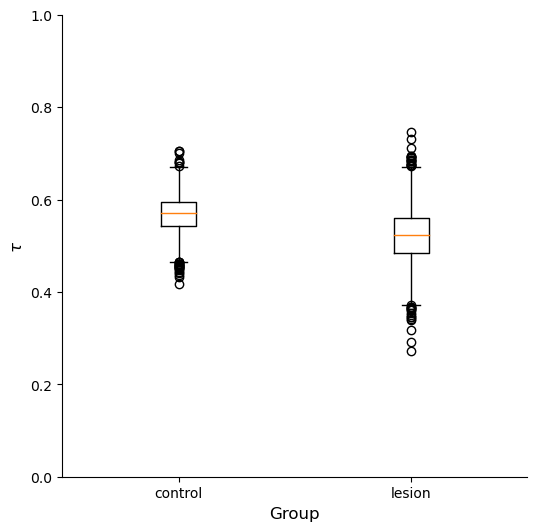

In [13]:
#%% Bootstrap and get population level tau
# randomly sampling trials in 5,000 iterations. The distribution of 
# differences between the obtained asymmetric scaling factors 

groups_resp = [per_cell_c,per_cell_l]
niterations = 5000
taus_pop,id_disc_pop,zcross_pop,zcross_rpe_pop,apos_pop,aneg_pop = [],[],[],[],[],[]
for iresp in groups_resp:
    per_cell = iresp.copy().transpose(1,0,2)
    ncells = per_cell.shape[0]
    id_samp = [np.random.choice(np.arange(ncells),ncells) for _ in range(niterations)]
    utility_axis = [np.floor(np.nanmean(np.nanmean(per_cell[ids,:,:],axis=2),axis=0)*1000)/1000 for ids in id_samp]
    m = [utils.compute_drl_metrics(np.nanmean(per_cell[ids,:,:],axis=0),utility_axis[ii],method_zcross) for (ii,ids) in enumerate(id_samp)]
    taus_,alpha_pos,alpha_neg,zcross_util,zcross_rpe,i_disc = utils.extract_metrics(m,utility_axis,rpes_x)
    taus_pop.append(taus_)
    zcross_pop.append(zcross_util)
    apos_pop.append(alpha_pos)
    aneg_pop.append(alpha_neg)
    zcross_rpe_pop.append(zcross_rpe)
    id_disc_pop.append(i_disc)

#%% Figure 5e
fig,ax = plt.subplots(figsize=(6,6))
ax.boxplot([taus_pop[0],taus_pop[1]])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.get_xaxis().tick_bottom()
ax.get_yaxis().tick_left()
ax.set_xlabel('Group',fontsize=12)
ax.set_ylabel(r'$\tau$',fontsize=12)
ax.set_xticklabels(groups)
ax.set_ylim([0,1])
p05 = np.percentile(taus_pop[1]-taus_pop[0],5)
print(p05) 
tests_pd.to_excel("analysis/tests_data_lhb.xlsx")